In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\Varun Raghu\Downloads\ecommerce_transactions_heavily_corrupted.csv")

In [3]:
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,-6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
pd.set_option('display.max.row',110)

In [5]:
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        104 non-null    int64  
 1   InvoiceNo    104 non-null    int64  
 2   StockCode    104 non-null    object 
 3   Description  104 non-null    object 
 4   Quantity     104 non-null    int64  
 5   InvoiceDate  104 non-null    object 
 6   UnitPrice    104 non-null    object 
 7   CustomerID   102 non-null    float64
 8   Country      104 non-null    object 
dtypes: float64(1), int64(3), object(5)
memory usage: 7.4+ KB


,index,InvoiceNo,Quantity,CustomerID
count,104.000000,104.000000,104.000000,102.000000
mean,50.528846,536371.894231,12.711538,15512.490196
std,29.002831,4.064811,16.702812,2320.944016
min,0.000000,536365.000000,-6.000000,12583.000000
25%,25.750000,536368.750000,6.000000,13047.000000
50%,51.500000,536373.000000,6.000000,14894.000000
75%,75.250000,536375.000000,12.000000,17850.000000
max,99.000000,536378.000000,120.000000,17850.000000


In [6]:
df = df.drop(columns=["index"])

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,-6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [8]:
df = df.dropna(subset=["CustomerID", "Description"]).copy()


In [9]:
df.isnull().sum()
df.shape


(102, 8)

In [10]:
df.loc[:, "UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")


In [11]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,-6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01/01/2035,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/10 8:34,1.69,13047.0,United Kingdom


In [12]:
df.loc[:, "InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)


C:\Users\Varun Raghu\AppData\Local\Temp\ipykernel_47544\2465797914.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.loc[:, "InvoiceDate"] = pd.to_datetime(


In [13]:
df = df[df["InvoiceDate"].notna()]
df = df[df["InvoiceDate"] < pd.Timestamp.today()]


In [14]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,-6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom
10,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,2010-12-01 08:34:00,2.1,13047.0,United Kingdom


In [15]:
df = df[df["Quantity"] > 0].copy()


In [16]:
df = df[df["UnitPrice"] > 0].copy()


In [17]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom
10,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,2010-12-01 08:34:00,2.1,13047.0,United Kingdom
11,536367,22748,POPPY'S PLAYHOUSE KITCHEN,6,2010-12-01 08:34:00,2.1,13047.0,United Kingdom


In [18]:
df["Country"].nunique()
df["Country"].value_counts().head()

Country
United Kingdom    75
France            17
Unted Kingdom      1
Name: count, dtype: int64

In [19]:
df.loc[:, "Country"] = df["Country"].replace({
    "Unted Kingdom": "United Kingdom"
})

In [20]:
df["Country"].value_counts()


Country
United Kingdom    76
France            17
Name: count, dtype: int64

In [21]:
df = df.drop_duplicates()


In [22]:
df.duplicated().sum()



np.int64(0)

In [23]:
df = df.copy()


In [24]:
df.loc[:, "Revenue"] = df["Quantity"] * df["UnitPrice"]


In [25]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.3
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.3


In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 0 to 98
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    90 non-null     int64  
 1   StockCode    90 non-null     object 
 2   Description  90 non-null     object 
 3   Quantity     90 non-null     int64  
 4   InvoiceDate  90 non-null     object 
 5   UnitPrice    90 non-null     object 
 6   CustomerID   90 non-null     float64
 7   Country      90 non-null     object 
 8   Revenue      90 non-null     object 
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ KB


In [27]:
df.isnull().sum()
df.describe()


,InvoiceNo,Quantity,CustomerID
count,90.000000,90.000000,90.000000
mean,536371.766667,11.777778,15481.788889
std,3.960621,13.392752,2330.576577
min,536365.000000,2.000000,12583.000000
25%,536368.250000,6.000000,13047.000000
50%,536373.000000,6.000000,14894.000000
75%,536375.000000,12.000000,17850.000000
max,536378.000000,80.000000,17850.000000


In [28]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.3
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.3
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.5
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.1
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08
10,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,2010-12-01 08:34:00,2.1,13047.0,United Kingdom,12.6
11,536367,22748,POPPY'S PLAYHOUSE KITCHEN,6,2010-12-01 08:34:00,2.1,13047.0,United Kingdom,12.6


In [29]:
df = df.reset_index(drop=True)


In [30]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.3
1,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.0
2,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
3,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.3
5,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.5
6,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.1
7,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08
8,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,2010-12-01 08:34:00,2.1,13047.0,United Kingdom,12.6
9,536367,22748,POPPY'S PLAYHOUSE KITCHEN,6,2010-12-01 08:34:00,2.1,13047.0,United Kingdom,12.6


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
avg_order_value = df.groupby("InvoiceNo")["Revenue"].sum().mean()

total_revenue, total_orders, avg_order_value

(2997.372666006447, 14, np.float64(214.09804757188914))

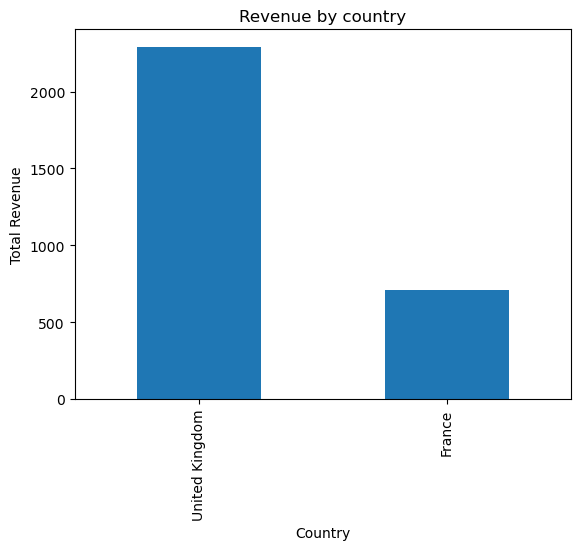

In [33]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_revenue.plot(kind="bar", title ="Revenue by country", xlabel ="Country", ylabel = "Total Revenue")
plt.show()


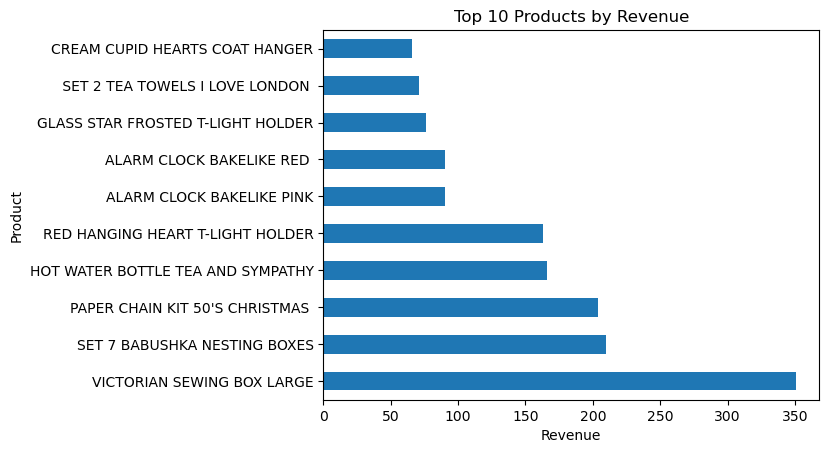

In [34]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(kind="barh", title="Top 10 Products by Revenue", xlabel="Revenue", ylabel="Product")
plt.show()

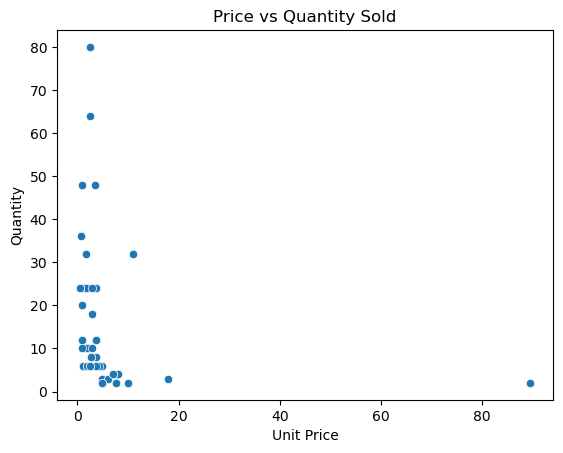

In [37]:
sns.scatterplot(
    x="UnitPrice",
    y="Quantity",
    data=df
)

plt.title("Price vs Quantity Sold")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.show()

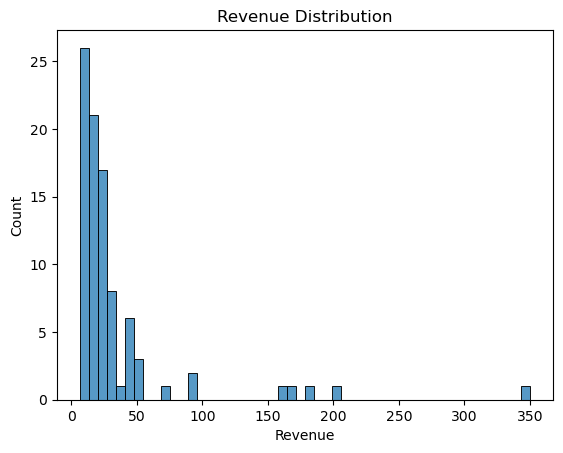

In [38]:
sns.histplot(df["Revenue"], bins=50)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.show()

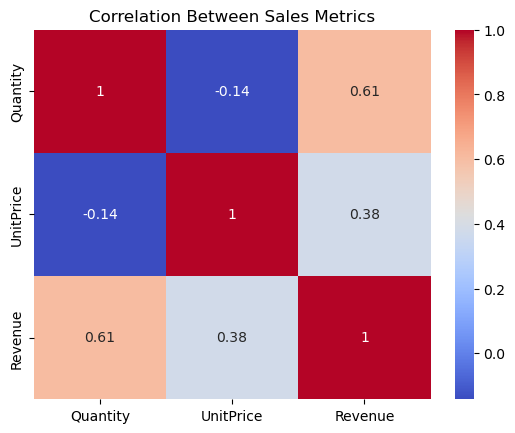

In [39]:
numeric_df = df[["Quantity", "UnitPrice", "Revenue"]]

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Sales Metrics")
plt.show()